In [2]:
import autogluon
import pandas as pd

# Autorzy
Jakub Melzacki (s27664)
Kacper Barański (s28166)

In [3]:
df = pd.read_csv('Car_sale_ads.csv')
df.head()

,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,...,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,...,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


In [4]:
df["Price"].describe()

count    2.083040e+05
mean     6.305383e+04
std      8.665967e+04
min      5.000000e+02
25%      1.780000e+04
50%      3.570000e+04
75%      7.599000e+04
max      6.999000e+06
Name: Price, dtype: float64

<Axes: >

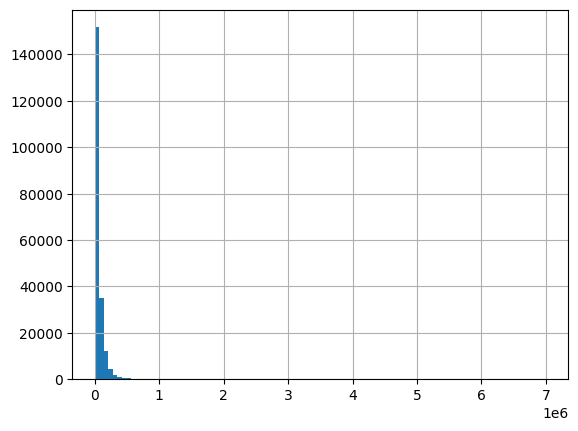

In [5]:
df["Price"].hist(bins=100)

<Axes: >

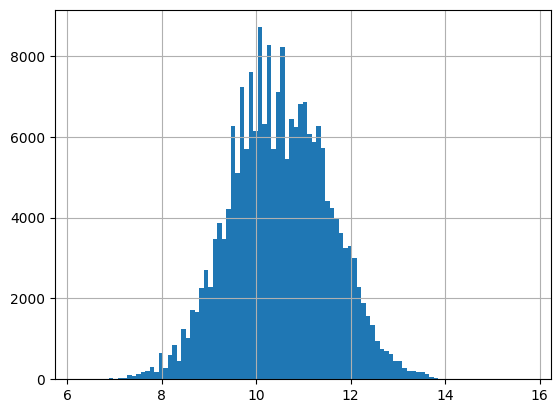

In [6]:
import numpy as np
df["Log_Price"] = np.log(df["Price"]) 
df["Log_Price"].hist(bins=100)  

In [7]:
# Remove price log outliers 2 standard deviations above the mean

# print("Len before outlier removal:", len(df))

# df = df[df["Log_Price"] <= df["Log_Price"].mean() + 2 * df["Log_Price"].std()].copy()

# print("Len after outlier removal:", len(df))

# Remove outliers in Log_Price IQR method
Q1 = df["Log_Price"].quantile(0.25)
Q3 = df["Log_Price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["Log_Price"] >= lower_bound) & (df["Log_Price"] <= upper_bound)].copy()

<Axes: >

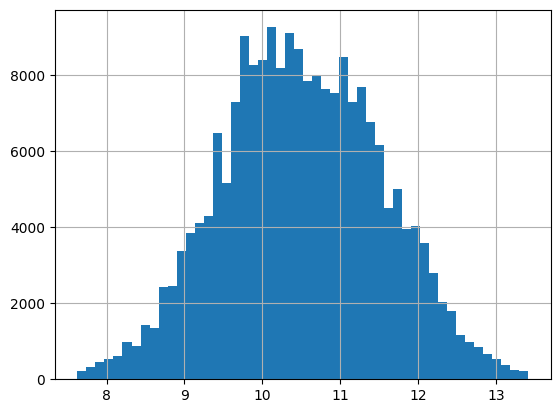

In [8]:
df["Log_Price"].hist(bins=50)  

In [9]:
df["Currency"].value_counts()

Currency
PLN    206830
EUR       265
Name: count, dtype: int64

In [10]:
# Remove EUR currency
df = df[df["Currency"] != "EUR"].copy()

In [11]:
# Remove outliers in Doors_number
df = df[df["Doors_number"] <= 7].copy()

In [12]:
# Combine "Brand" and "Model" into a new column "Brand_Model" if Model is not null
df["Brand_Model"] = df["Vehicle_brand"] + " " + df["Vehicle_model"].fillna("")

In [13]:
len(df["Vehicle_model"].value_counts())


1172

In [14]:
# Target encoding for "Brand_Model"
brand_model_means = df.groupby("Brand_Model")["Log_Price"].mean()

df["Brand_Model_Encoded"] = df["Brand_Model"].map(brand_model_means)


In [15]:
# Target encoding for "Vehicle_brand"
vehicle_brand_means = df.groupby("Vehicle_brand")["Log_Price"].mean()
df["Vehicle_brand_Encoded"] = df["Vehicle_brand"].map(vehicle_brand_means)

In [16]:
# df["Condition"].isna().sum()
# df["Condition"].fillna("Unknown", inplace=True)
columns = ["Condition", "Fuel_type", "Drive", "Type", "Doors_number"]
df = pd.get_dummies(df, columns=columns, prefix=columns, dummy_na=True)

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer


def clean_features(text):
    if pd.isna(text):
        return []
    cleaned = text.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [f.strip() for f in cleaned.split(",") if f.strip()]

df['feat_list'] = df['Features'].apply(clean_features)

mlb = MultiLabelBinarizer()
encoded_data = mlb.fit_transform(df['feat_list'])

df_encoded = pd.DataFrame(encoded_data, columns=mlb.classes_, index=df.index)
df.drop(columns=['feat_list'], inplace=True)  # Usuwamy tymczasową kolumnę z listami
df.drop(columns=['Features'], inplace=True)  # Usuwamy oryginalną kolumnę z tekstem
# 4. Łączymy z oryginalnym DataFrame
df = pd.concat([df, df_encoded], axis=1)
df.head()

,Index,Price,Currency,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,Power_HP,...,Shift paddles,Speed limiter,Start-Stop system,Sunroof,TV tuner,Tinted windows,Twilight sensor,USB socket,Velor upholstery,Xenon lights
0,0,86200,PLN,Abarth,595,NaN,NaN,2021,1.0,145.0,...,0,0,0,0,0,0,0,0,0,0
1,1,43500,PLN,Abarth,Other,NaN,NaN,1974,59000.0,75.0,...,0,0,0,0,0,0,0,0,0,0
2,2,44900,PLN,Abarth,500,NaN,NaN,2018,52000.0,180.0,...,0,0,0,0,0,0,0,0,0,0
3,3,39900,PLN,Abarth,500,NaN,NaN,2012,29000.0,160.0,...,0,0,0,0,0,0,0,1,0,1
4,4,97900,PLN,Abarth,595,NaN,NaN,2021,600.0,165.0,...,0,0,0,0,0,1,0,1,0,0


In [18]:
df.columns

Index(['Index', 'Price', 'Currency', 'Vehicle_brand', 'Vehicle_model',
       'Vehicle_version', 'Vehicle_generation', 'Production_year',
       'Mileage_km', 'Power_HP',
       ...
       'Shift paddles', 'Speed limiter', 'Start-Stop system', 'Sunroof',
       'TV tuner', 'Tinted windows', 'Twilight sensor', 'USB socket',
       'Velor upholstery', 'Xenon lights'],
      dtype='object', length=129)

In [19]:
to_drop = ["Index", "Vehicle_brand", "Origin_country", "Vehicle_version", "Vehicle_generation", "Vehicle_model", "Brand_Model", "Currency", "Price", "CO2_emissions", "Transmission", "Colour", 'First_registration_date', 'Offer_publication_date', 'Offer_location', "First_owner"]
df.drop(columns=to_drop, inplace=True)
df.head()

,Production_year,Mileage_km,Power_HP,Displacement_cm3,Log_Price,Brand_Model_Encoded,Vehicle_brand_Encoded,Condition_New,Condition_Used,Condition_nan,...,Shift paddles,Speed limiter,Start-Stop system,Sunroof,TV tuner,Tinted windows,Twilight sensor,USB socket,Velor upholstery,Xenon lights
0,2021,1.0,145.0,1400.0,11.364425,11.226580,11.01378,True,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1974,59000.0,75.0,1100.0,10.680516,10.585895,11.01378,False,True,False,...,0,0,0,0,0,0,0,0,0,0
2,2018,52000.0,180.0,1368.0,10.712193,10.700989,11.01378,False,True,False,...,0,0,0,0,0,0,0,0,0,0
3,2012,29000.0,160.0,1368.0,10.594132,10.700989,11.01378,False,True,False,...,0,0,0,0,0,0,0,1,0,1
4,2021,600.0,165.0,1368.0,11.491702,11.226580,11.01378,True,False,False,...,0,0,0,0,0,1,0,1,0,0


In [20]:
# Standardize numerical features
features_to_normalize = ["Mileage_km", "Displacement_cm3", "Power_HP"]

for feature in features_to_normalize:
    mean = df[feature].mean()
    std = df[feature].std()
    df[feature] = (df[feature] - mean) / std

In [21]:
# Minmax year of production
df["Production_year"] = (df["Production_year"] - df["Production_year"].min()) / (df["Production_year"].max() - df["Production_year"].min())

In [22]:
df = df.reset_index(drop=True)
X = df.drop(columns=["Log_Price"])
y = df["Log_Price"]

len(X)

205355

In [23]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    reg = LGBMRegressor(
        **params,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    score = cross_val_score(reg, X, y, cv=3, scoring="r2", n_jobs=1).mean()
    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Najlepszy wynik (R^2 Score):", study.best_value)
print("Najlepsze parametry:", study.best_params)


[I 2026-06-02 16:55:47,034] A new study created in memory with name: no-name-9f3e58a9-a891-4fd6-85a5-31164a20431d
[I 2026-06-02 16:55:57,081] Trial 0 finished with value: 0.9244569358401891 and parameters: {'n_estimators': 845, 'learning_rate': 0.03347726087656361, 'num_leaves': 111, 'max_depth': 6, 'min_child_samples': 63, 'subsample': 0.9638309341403828, 'colsample_bytree': 0.873669864652704, 'reg_alpha': 1.716070614018723e-06, 'reg_lambda': 5.830796280680483}. Best is trial 0 with value: 0.9244569358401891.
[I 2026-06-02 16:56:04,907] Trial 1 finished with value: 0.9209078062176888 and parameters: {'n_estimators': 527, 'learning_rate': 0.011012249221957333, 'num_leaves': 39, 'max_depth': 9, 'min_child_samples': 67, 'subsample': 0.6401428789016201, 'colsample_bytree': 0.8349312393603147, 'reg_alpha': 0.26170855627871886, 'reg_lambda': 6.665833480152813e-08}. Best is trial 0 with value: 0.9244569358401891.
[I 2026-06-02 16:56:13,746] Trial 2 finished with value: 0.9240812604639507 and

Najlepszy wynik (R^2 Score): 0.9252835693019872
Najlepsze parametry: {'n_estimators': 907, 'learning_rate': 0.03592011897996715, 'num_leaves': 36, 'max_depth': 10, 'min_child_samples': 92, 'subsample': 0.9339197568968421, 'colsample_bytree': 0.6456091752433072, 'reg_alpha': 1.755722875753481e-05, 'reg_lambda': 0.27405643930393986}
